# Проект спринта 10. Прогнозирование массы морских черепах по результатам внешних измерений.

## Цель и задачи  

**Цель:** Разработка механизма определения массы морских черепах `Chelonia mydas` по результатам измерений, полученным из системы компьютерного зрения.   

**Задачи:**
1. Загрузка данных и знакомство с их содержимым.
2. Исследовательский анализ данных.
3. Предобработка данных для машинного обучения.
4. Разработка механизма предсказания массы черепах.
    - Обучение нескольких моделей линейной регрессии с разными параметрами.
    - Сравнение моделей по метрикам MAE, MAPE, SE, RMSE, R2 на валидационной выборке.
    - Проверка лучшей модели на тестовой выборке.
    - Разработка функции прогнозирования массы черепахи по заданным параметрам.
5. Формулировка выводов и рекомендаций по использованию модели.

## Данные

Для анализа поступили данные в формате CSV-файла, который доступен по ссылке [turtles.csv](https://code.s3.yandex.net/datasets/turtles.csv).
Данные содержат следующие поля:

- `id` — идентификатор измерения.
- `binomial_name` — международное научное название вида черепахи.
- `registration_number` — регистрационный номер черепахи.
- `shell_length` — длина панциря, мм.
- `shell_width` — ширина панциря, мм.
- `head_length` — длина головы, мм.
- `head_width` — ширина головы, мм.
- `flipper_length_n` — длина одной ласты, мм. У черепах четыре ласты, поэтому в датасете четыре таких столбца, в названиях вместо `n` указан номер от `1` до `4`.
- `flipper_width_n` — ширина одной ласты, мм. У черепах четыре ласты, поэтому в датасете четыре таких столбца, в названиях вместо `n` указан номер от `1` до `4`.
- `circle_count` — количество колец роста на панцире черепахи.
- `measure_count` — количество измерений, которые произвели, прежде чем усреднить показатели черепахи и добавить их в таблицу.
- `shell_crack` — наличие трещин панциря.
- `timestamp` — время внесения данных о черепахе.
- `weight` — масса черепахи, кг.

## Структура проекта

1. [Загрузка данных и знакомство с их содержимым.](#1-загрузка-данных-и-знакомство-с-ними)
2. [Предобработка данных.](#2-предобработка-данных)
    - 2.1. [Обработка пропусков и дубликатов.](#21-обработка-пропусков-и-дубликатов)
    - 2.2. [Исследование категориальных и временных значений.](#22-исследование-категориальных-и-временных-значений)
    - 2.3. [Исследование числовых значений.](#23-исследование-числовых-значений)
    - 2.4. [Исследование корреляции веса с параметрами измерений.](#24-исследование-корреляции-веса-с-параметрами-измерений)
    - 2.5. [Проверка на мультколлинеарность.](#25-проверка-на-мультиколлинеарность)
3. [Подготовка данных для машинного обучения.](#3-подготовка-данных-для-машинного-обучения)
4. [Обучение линейных моделей.](#4-обучение-линейных-моделей)
5. [Уменьшение количества признаков.](#5-уменьшение-количества-признаков)
6. [Разработка функции предсказания веса по результатам измерений.](#6-разработка-функции-предсказания-веса-по-результатам-измерений)
7. [Выводы.](#7-выводы)


## 1. Загрузка данных и знакомство с ними

- Устанавливаем зависимости и импортируем необходимые библиотеки:

In [1]:
%pip install -q scikit-learn
%pip install -q --upgrade seaborn
%pip install -q --upgrade jinja2

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import math

import pandas as pd
import numpy as np

# Библиотеки машинного обучения
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.dummy import DummyRegressor

# Библиотеки для построения графиков
import seaborn as sns
import matplotlib.pyplot as plt

# Для форматирования в HTML
from IPython.display import display, HTML, Markdown

- Загрузим данные и выведем сведения о них:

In [3]:
df = pd.read_csv('https://code.s3.yandex.net/datasets/turtles.csv', sep='\t', decimal=',')

print(df.info())
display(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 8861 entries, 0 to 8860
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   8861 non-null   int64  
 1   binomial_name        8812 non-null   str    
 2   registration number  8832 non-null   str    
 3   shell_length         8774 non-null   float64
 4   shell_width          8861 non-null   int64  
 5   head_length          8715 non-null   float64
 6   head_width           8715 non-null   float64
 7   flipper_length_1     8861 non-null   int64  
 8   flipper_width_1      8861 non-null   int64  
 9   flipper_length_2     8861 non-null   int64  
 10  flipper_width_2      8861 non-null   int64  
 11  flipper_length_3     8760 non-null   float64
 12  flipper_width_3      8760 non-null   float64
 13  flipper_length_4     8760 non-null   float64
 14  flipper_width_4      8760 non-null   float64
 15  circle_count         8861 non-null   int64  
 16 

,id,binomial_name,registration number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
0,20438,Caretta caretta,d89af72662f49ece4d09dec75a8b0166,700.0,381,112.0,82.0,356,205,331,185,270.0,180.0,273.0,144.0,63,3.0,NaN,1703159226,87.687
1,19034,Lepidochelys olivacea,1579c64777de4db1c16e8b7b0d19c45e,341.0,295,65.0,48.0,216,190,229,186,164.0,182.0,180.0,149.0,0,1.0,1.0,1689428175,26.949
2,24689,LEPIDOCHELYS OLIVACEA,bfcec01187569615087e4d777c44985a,408.0,343,71.0,70.0,308,224,285,232,264.0,179.0,268.0,176.0,0,3.0,NaN,1745783111,30.016
3,17945,Lepidochelys Olivacea,2c159675aa28f0ea566fce2090bf4c82,512.0,432,98.0,95.0,334,317,364,284,NaN,NaN,NaN,NaN,3,4.0,1.0,1677757151,33.917
4,24543,lepidochelys olivacea,ecd22499761e2ac56a6d8eb765ec566d,408.0,307,50.0,54.0,280,168,269,218,199.0,165.0,209.0,180.0,0,4.0,1.0,1744455613,28.511


- Выведем все названия видов черепах:

In [4]:
display(pd.Series(df['binomial_name'].unique()).sort_values())

10           CARETTA CARETTA
13            CHELONIA MYDAS
17           Caretta Caretta
0            Caretta caretta
12            Chelonia Mydas
5             Chelonia mydas
23      DERMOCHELYS CORIACEA
14      Dermochelys Coriacea
8       Dermochelys coriacea
6     ERETMOCHELYS IMBRICATA
20    Eretmochelys Imbricata
7     Eretmochelys imbricata
2      LEPIDOCHELYS OLIVACEA
22       Lepidochelys Kempii
3      Lepidochelys Olivacea
19       Lepidochelys kempii
1      Lepidochelys olivacea
9            caretta caretta
11            chelonia mydas
21      dermochelys coriacea
15    eretmochelys imbricata
18       lepidochelys kempii
4      lepidochelys olivacea
16                       NaN
dtype: str

- Среди названий видов присутствуют неявные дубликаты, отличающиеся регистром символов. Приведем названия в столбце `binomial_name` к нижнему регистру и отберем только интересующие нас данные (для вида `Chelonia mydas`):

In [5]:
df['binomial_name'] = df['binomial_name'].str.lower()
df = df[df['binomial_name'] == 'chelonia mydas']

initial_count = len(df)
print(f"Количество строк для вида Chelonia mydas: {initial_count}")

Количество строк для вида Chelonia mydas: 2829


- Доля пропусков в столбцах в процентах:

In [6]:
display(round(df.isna().sum() / initial_count * 100, 2))

df_no_meas_misses = df.dropna(subset=['shell_length',
                                           'head_length',
                                           'head_width',
                                           'flipper_length_3',
                                           'flipper_width_3',
                                           'flipper_length_4',
                                           'flipper_width_4',
                                           'weight'])

meas_misses_count = initial_count - len(df_no_meas_misses)

print(f"Количество строк с пропусками в измерениях: {meas_misses_count} ({meas_misses_count / initial_count * 100:.2f})%")
print("Значения в поле shell_crack: ", df['shell_crack'].unique())

id                      0.00
binomial_name           0.00
registration number     0.14
shell_length            1.24
shell_width             0.00
head_length             1.38
head_width              1.38
flipper_length_1        0.00
flipper_width_1         0.00
flipper_length_2        0.00
flipper_width_2         0.00
flipper_length_3        1.10
flipper_width_3         1.10
flipper_length_4        1.10
flipper_width_4         1.10
circle_count            0.00
measure_count           2.86
shell_crack            76.07
timestamp               0.00
weight                  0.11
dtype: float64

Количество строк с пропусками в измерениях: 105 (3.71)%
Значения в поле shell_crack:  [ 1.  5. nan  3.  2.  4.]


**Выводы:**
- В 105 строках (3.71%) отсутствуют такие важные для обучения модели признаки, как вес, длина панциря, длина и ширина головы, задних плавников. Вероятно, отсутствие этих данных связано с тем, что черепаха в течение всех измерений занимала неподходящее для вычисления этих параметров положение относительно камеры. Эти данные можно удалить. Вес является целевой переменной для прогноза, поэтому строки с пропуском в этом поле однозначно подлежат удалению.
- Столбец с длиной панциря `shell_length` имеет тип `float64`, тогда как столбец с шириной панциря `shell_width` - `int64`. Это связано с пропусками в поле `shell_length`. После обработки пропусков тип можно будет преобразовать к `int`.
- Столбцы `head_length`, `head_width`, `flipper_length_3`, `flipper_widgth_3`, `flipper_length_4`, `flipper_widgth_4` по причине наличия пропусков также имеют тип `float64`. После обработки пропусков тип можно будет преобразовать к `int`.
- Столбец `measure_count` из-за наличия пропусков получил тип `float64`. Необходимо преобразовать тип к `int`. Пропуски в `measure_count` можно заменить на нули, так как этот параметр не является характеристикой черепахи и не будет использоваться в качестве признака при обучении модели.
- Столбец `shell_crack` имеет тип `float64`. Пропуски в значениях, очевидно, соответствуют отсутствию трещин, а непустые значения - их количеству. Пропуски можно заменить на нули, а тип столбца - преобразовать к `int`.
- Столбец `registration number` является строковым и не будет непосредственно использоваться в обучении модели, поэтому пропуски в нем можно заполнить индикатором `undefined`.
- Имя столбца `registration number` следует преобразовать к snake case.
- Столбец `timestamp` содержит время в формате UNIX, можно преобразовать его в `datetime`

## 2. Предобработка данных.

### 2.1. Обработка пропусков и дубликатов
- Определим функции, которые будут использоваться для построения диаграмм:

In [7]:
# Функция для построения скаттерплота
def draw_scatterplot(data, 
                     title, 
                     x, 
                     y, 
                     hue,
                     xlabel, 
                     ylabel,
                     figsize=(12, 6)):
    plt.figure(figsize=figsize)
    sns.scatterplot(data=data, 
                    x=x,
                    y=y,
                    hue=hue)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()

# Функция для построения скаттерплота в сетке
def draw_scatterplot_grid(data, 
                     title, 
                     x, 
                     y, 
                     hue,
                     xlabel, 
                     ylabel,
                     ax):
    sns.scatterplot(data=data, 
                    x=x,
                    y=y,
                    hue=hue, 
                    ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

# Функция для построения джойнтплота
def draw_jointplot(data, 
                   title, 
                   x, 
                   y, 
                   hue, 
                   xlabel, 
                   ylabel, 
                   figsize=(12, 6)):
    g = sns.jointplot(data=data, 
                    x=x,
                    y=y,
                    hue=hue,
                    marginal_kws={"common_norm": False})
    
    g.set_axis_labels(xlabel, ylabel)
    g.fig.set_size_inches(*figsize)
    g.fig.suptitle(title, fontsize=14)
    g.fig.tight_layout()
    g.fig.subplots_adjust(top=0.92)
    plt.show()
    plt.close(g.fig)

# Функция для построения боксплота
def draw_boxplot(data, 
                 title, 
                 hue, 
                 xlabel, 
                 ylabel, 
                 figsize=(12, 6)):
    plt.figure(figsize=figsize)
    sns.boxplot(data=data,
            showmeans=True,
            legend=False,
            meanprops={
                "marker": "o",
                "markerfacecolor": "white",
                "markeredgecolor": "black",
                "markersize": 8
            },
            orient='h',
            hue=hue)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

# Функция для построения гистограммы
def draw_kdeplot(data,
                   title,
                   xlabel, 
                   ylabel, 
                   figsize=(12, 4),
                   **kwargs):
    plt.figure(figsize=figsize)
    sns.kdeplot(data=data,
                 **kwargs)

    # plt.xticks(np.arange(0, 1300, step=50), rotation=90)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

# Функция для построения столбчатой диаграммы
def draw_barplot(series, 
                 title, 
                 xlabel, 
                 ylabel, 
                 rot=0, 
                 vertical=True, 
                 mean=None):
    series.head(10).plot(
        title=title,
        kind='bar' if vertical else 'barh',
        figsize=(8, 4) if vertical else (12, 4),
        xlabel=xlabel if vertical else ylabel,
        ylabel=ylabel if vertical else xlabel,
        grid=True,
        rot=rot)
    
    if mean != None:
        if vertical:
            plt.axhline(mean, color='red', linestyle='--')
        else:
            plt.axvline(mean, color='red', linestyle='--')
    plt.show()

# Функция для построения тепловой карты
def draw_heatmap(df, title, figsize=(12,12)):
    plt.figure(figsize=figsize)
    plt.title(title)
    sns.heatmap(data=df, annot=True, fmt='.2f', linewidths=0.5, cmap='viridis')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()    

- Обработаем строки с пропусками и преобразуем типы данных столбцов датасета:

In [8]:
# Удаляем пропуски в измерениях параметров черепахи
df = df_no_meas_misses

# Подготовка к преобразованию типов к int и float
df.fillna({'shell_crack': 0, 'measure_count': '0'}, inplace=True)

int_cols = ['shell_length',
                 'shell_width',
                 'head_length',
                 'head_width',
                 'flipper_length_1',
                 'flipper_width_1',
                 'flipper_length_2',
                 'flipper_width_2',
                 'flipper_length_3',
                 'flipper_width_3',
                 'flipper_length_4',
                 'flipper_width_4',
                 'circle_count',
                 'measure_count',
                 'shell_crack']

# Преобразуем типы целочисленных столбцов
df[int_cols] = df[int_cols].apply(pd.to_numeric, downcast='integer')

# Переименуем столбец
df.rename(columns={'registration number': 'registration_number'}, inplace=True)
# Заполним пропуски в строковых столбцах
df.fillna({'registration_number': 'undefined'}, inplace=True)
# Преобразуем столбец timestamp к типу datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')

df.info()
display(df.head())

last_count = len(df)
meas_misses_count = initial_count - last_count
print(f"Удалено {meas_misses_count} строк.")

<class 'pandas.DataFrame'>
Index: 2724 entries, 8 to 8859
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype        
---  ------               --------------  -----        
 0   id                   2724 non-null   int64        
 1   binomial_name        2724 non-null   str          
 2   registration_number  2724 non-null   str          
 3   shell_length         2724 non-null   int16        
 4   shell_width          2724 non-null   int16        
 5   head_length          2724 non-null   int16        
 6   head_width           2724 non-null   int16        
 7   flipper_length_1     2724 non-null   int16        
 8   flipper_width_1      2724 non-null   int16        
 9   flipper_length_2     2724 non-null   int16        
 10  flipper_width_2      2724 non-null   int16        
 11  flipper_length_3     2724 non-null   int16        
 12  flipper_width_3      2724 non-null   int16        
 13  flipper_length_4     2724 non-null   int16        
 14  flipper_

,id,binomial_name,registration_number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
8,25241,chelonia mydas,0d05dca974d9f624d9c9f8e38817f827,742,652,118,147,411,386,507,389,414,368,311,325,66,4,1,2025-06-29 20:23:23,56.352
11,20099,chelonia mydas,36e7d3b61a0d557e45ad4b39bb2ec512,1336,1318,207,248,845,704,661,768,587,686,661,585,111,2,5,2023-11-13 22:19:10,154.074
16,18213,chelonia mydas,cbb98eb064c1dcefd1a009b21656500f,1010,926,216,156,562,488,529,432,467,434,553,463,76,1,0,2023-03-31 23:05:01,87.695
21,20839,chelonia mydas,8c20d754391001ef4cda77701123f4bc,982,940,187,157,518,557,545,463,497,511,541,479,103,2,0,2024-02-06 13:49:28,92.707
23,18151,chelonia mydas,17ee6cadc77c0f418dbea1acaa998441,887,813,149,140,578,514,538,472,462,308,408,396,70,4,0,2023-03-26 04:16:53,75.829


Удалено 105 строк.


- Проверим датасет на дубликаты и удалим их с исключением столбцов `id`, `registration_number`:

In [9]:
dup_columns = df.columns.to_list()
dup_columns.remove('id')
dup_columns.remove('registration_number')

dup_count = df.duplicated(subset=dup_columns).sum()
df = df.drop_duplicates(subset=dup_columns)

print(f"Количество удаленных дубликатов: {dup_count}.")
last_count = len(df)
print(f"Суммарное количество удаленных строк: {initial_count - last_count} ({(initial_count - last_count) / initial_count * 100:.2f})%")
print("Количество строк в датасете: ", last_count)

Количество удаленных дубликатов: 328.
Суммарное количество удаленных строк: 433 (15.31)%
Количество строк в датасете:  2396


**Вывод:** На данном этапе предобработки были удалены 105 строк с пропусками в измерениях и 328 дубликатов. Датасет сократился на 433 строки (или 15.31%).

### 2.2. Исследование категориальных и временных значений.

В приведенном датасете только один категориальный столбец - название вида черепахи `binomial_name`. Проверим, что нет других категорий:

In [10]:
display(pd.Series(df['binomial_name'].unique()).sort_values())

0    chelonia mydas
dtype: str

- Проверим данные о времени наблюдений:

In [11]:
print(f"Даты наблюдений с {df['timestamp'].min()} по {df['timestamp'].max()}.")

Даты наблюдений с 2023-01-01 10:47:51 по 2025-07-04 00:18:01.


**Выводы:**
- Датасет был отфильтрован правильно, в столбце `binomial_name` только одно значение - `chelonia mydas`.
- Данные о времени наблюдений корректны.

### 2.3. Исследование числовых значений.

- Статистики по числовым параметрам:

In [12]:
def show_numeric_stat():
    display(df[int_cols].describe(percentiles=[0.25, 0.50, 0.75, 0.80, 0.90, 0.95, 0.99, 0.995]))
    print("Статистики для веса:")
    display(df['weight'].describe(percentiles=[0.25, 0.50, 0.75, 0.80, 0.90, 0.95, 0.99, 0.995]))

show_numeric_stat()

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack
count,2396.000000,2396.000000,2396.000000,2396.000000,2396.000000,2396.000000,2396.000000,2396.000000,2396.000000,2396.000000,2396.000000,2396.000000,2396.000000,2396.000000,2396.000000
mean,1048.943239,946.114357,169.601419,183.053005,612.154424,549.551336,611.876461,550.731636,487.274624,440.653172,489.369783,441.166945,80.904007,2.419032,0.416110
std,574.727627,514.994624,41.295475,45.087946,141.961177,131.515230,138.171854,130.765606,110.172469,105.235199,112.254956,104.316087,16.186181,1.174413,0.952338
min,645.000000,564.000000,87.000000,96.000000,339.000000,245.000000,327.000000,276.000000,282.000000,231.000000,254.000000,243.000000,29.000000,0.000000,0.000000
25%,837.000000,755.000000,138.000000,148.000000,502.000000,450.000000,505.000000,449.000000,400.000000,357.000000,400.000000,360.000000,70.000000,1.000000,0.000000
50%,980.500000,890.000000,163.000000,176.000000,588.000000,528.000000,591.000000,533.500000,473.000000,426.000000,473.000000,423.000000,80.000000,2.000000,0.000000
75%,1170.500000,1055.000000,195.000000,212.000000,702.000000,631.000000,703.000000,635.250000,558.000000,511.000000,563.000000,509.000000,91.000000,3.000000,0.000000
80%,1223.000000,1100.000000,203.000000,220.000000,735.000000,658.000000,727.000000,662.000000,583.000000,532.000000,588.000000,531.000000,94.000000,4.000000,1.000000
90%,1344.500000,1225.000000,228.000000,248.000000,820.500000,734.000000,806.000000,737.000000,648.000000,587.500000,649.000000,592.000000,103.000000,4.000000,1.000000
95%,1451.000000,1308.000000,249.000000,267.250000,878.500000,797.000000,872.250000,793.250000,689.250000,635.000000,699.000000,636.000000,109.000000,4.000000,2.000000


Статистики для веса:


count    2396.000000
mean       96.051661
std        34.988126
min         0.000000
25%        67.538750
50%        88.178500
75%       117.542250
80%       125.421000
90%       148.231500
95%       166.151750
99%       189.622800
99.5%     193.876850
max       199.961000
Name: weight, dtype: float64

- Построим боксплоты для распределения измерений:

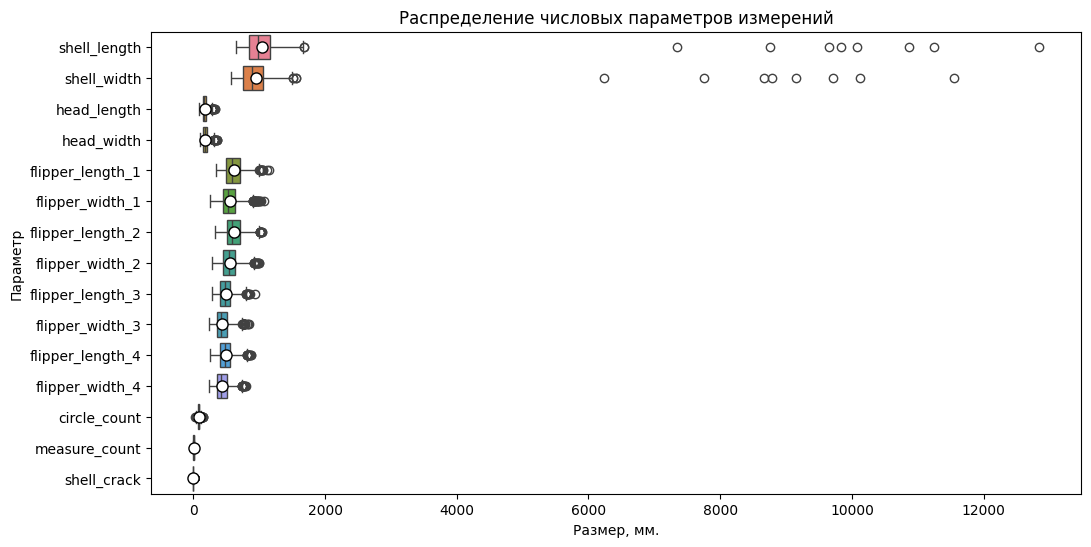

In [13]:
draw_boxplot(df[int_cols],
             "Распределение числовых параметров измерений",
             None,
             "Размер, мм.",
             "Параметр")

- В столбцах `shell_length` и `shell_width` присутствуют выбросы до 12840 мм. Очевидно, это ошибка, о которой говорилось в сообщении заказчика (значения умножены на 10). Необходимо выяснить, какие из значений нуждаются в коррекции.
- Присутствуют записи с нулевым весом. Их необходимо удалить, так как они некорректны и будут искажать обучение.
- Остальные числовые значения находятся в допустимых пределах для черепах вида `chelonia mydas`.

Удалим записи с нулевыми весами и построим скаттерплот зависимости веса от длины и ширины панциря, чтобы определить искаженные измерения:

Удалено 3 строк.
Новое количество строк: 2393


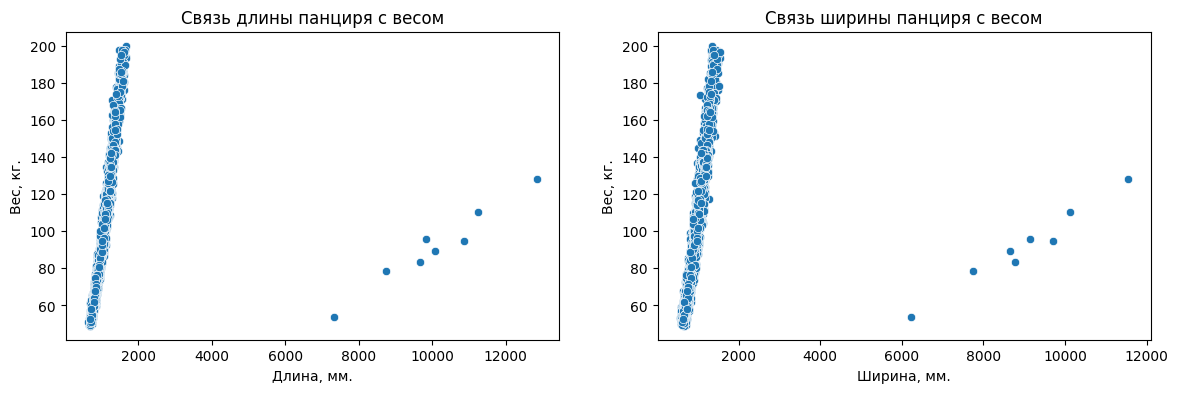

In [14]:
# Удалим записи с весом 0
df = df[df['weight'] > 0]
print(f"Удалено {last_count - len(df)} строк.")
print(f"Новое количество строк: {len(df)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

draw_scatterplot_grid(df, 
                 "Связь длины панциря с весом",
                'shell_length',
                'weight',
                None,
                "Длина, мм.",
                "Вес, кг.",
                axes[0])

draw_scatterplot_grid(df, 
                 "Связь ширины панциря с весом",
                'shell_width',
                'weight',
                None,
                "Ширина, мм.",
                "Вес, кг.",
                axes[1])

На диаграмме видно, что в коррекции нуждаются значения длины и ширины более 6000. Скорректируем их путем деления на 10:

In [15]:
df.loc[df['shell_length'] > 6000, 'shell_length'] /= 10
df.loc[df['shell_width'] > 6000, 'shell_width'] /= 10

- Обновленные диаграммы распределения и статистики по числовым параметрам:

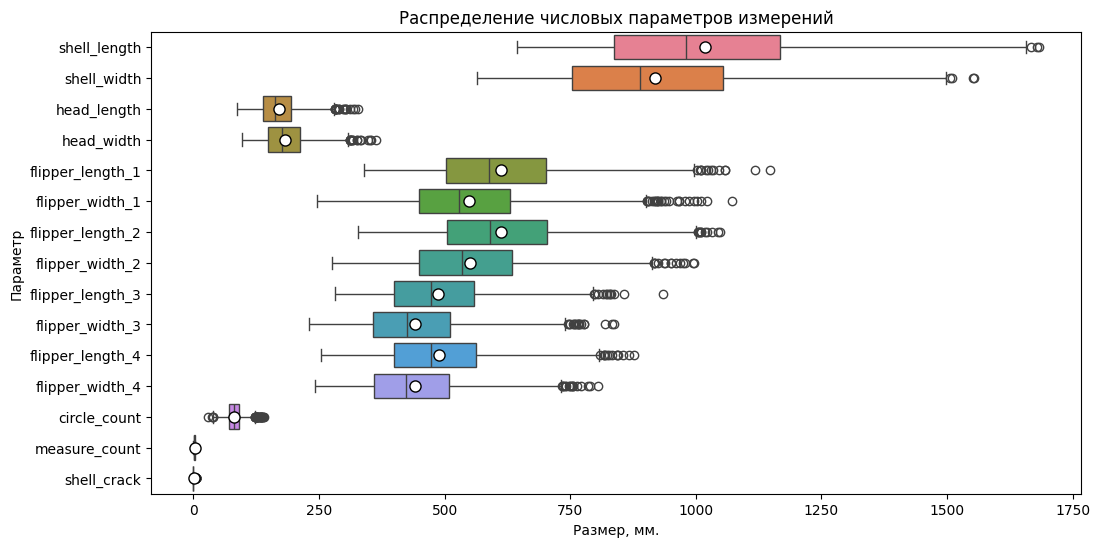

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack
count,2393.000000,2393.000000,2393.000000,2393.000000,2393.000000,2393.000000,2393.000000,2393.000000,2393.000000,2393.000000,2393.000000,2393.000000,2393.000000,2393.000000,2393.000000
mean,1018.613038,919.001672,169.592144,183.043042,612.060593,549.536147,611.823234,550.681153,487.234434,440.586711,489.392812,441.125784,80.895947,2.418721,0.416632
std,221.893256,202.043414,41.264553,45.077110,141.837037,131.483959,138.101688,130.791969,110.110794,105.207770,112.267007,104.252285,16.184543,1.174642,0.952821
min,645.000000,564.000000,87.000000,96.000000,339.000000,245.000000,327.000000,276.000000,282.000000,231.000000,254.000000,243.000000,29.000000,0.000000,0.000000
25%,837.000000,754.000000,138.000000,148.000000,502.000000,450.000000,505.000000,449.000000,400.000000,357.000000,400.000000,360.000000,70.000000,1.000000,0.000000
50%,980.000000,889.000000,163.000000,176.000000,588.000000,528.000000,591.000000,534.000000,473.000000,426.000000,473.000000,423.000000,80.000000,2.000000,0.000000
75%,1167.000000,1054.000000,195.000000,212.000000,702.000000,631.000000,703.000000,635.000000,558.000000,511.000000,563.000000,509.000000,91.000000,3.000000,0.000000
80%,1220.000000,1097.000000,203.000000,220.000000,734.200000,658.000000,727.000000,662.000000,583.000000,531.600000,587.600000,531.000000,94.000000,4.000000,1.000000
90%,1339.400000,1216.800000,228.000000,248.000000,820.000000,734.000000,806.000000,737.000000,648.000000,587.000000,649.000000,592.000000,103.000000,4.000000,1.000000
95%,1441.400000,1293.800000,248.400000,267.400000,878.000000,797.000000,872.000000,793.400000,689.000000,635.000000,699.000000,634.800000,109.000000,4.000000,2.000000


Статистики для веса:


count    2393.000000
mean       96.172077
std        34.844208
min        49.045000
25%        67.620000
50%        88.227000
75%       117.555000
80%       125.488200
90%       148.237200
95%       166.154000
99%       189.632280
99.5%     193.891760
max       199.961000
Name: weight, dtype: float64

In [16]:
draw_boxplot(df[int_cols],
             "Распределение числовых параметров измерений",
             None,
             "Размер, мм.",
             "Параметр")
show_numeric_stat()

- Построим диаграммы плотности распределения числовых параметров:

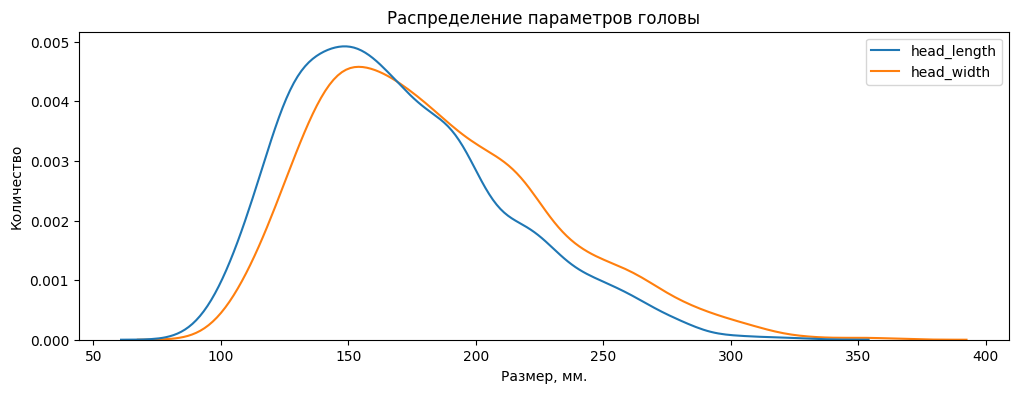

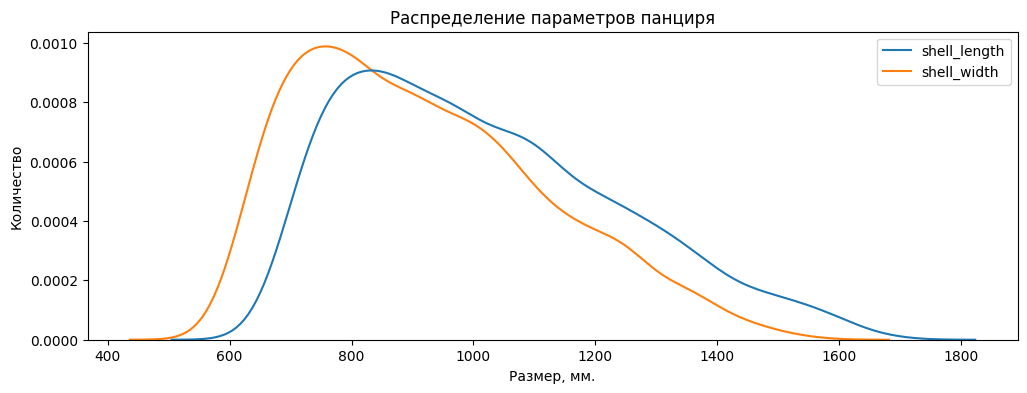

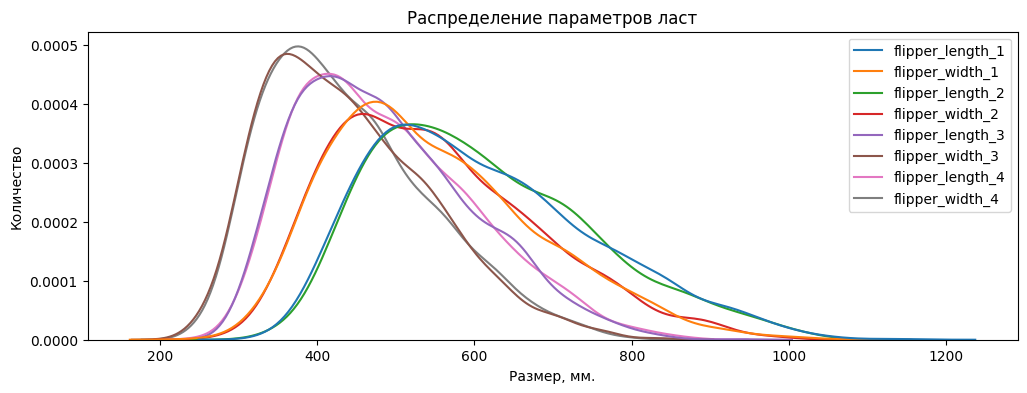

In [17]:
draw_kdeplot(df[['head_length', 'head_width']],
               "Распределение параметров головы",
               "Размер, мм.",
               "Количество")
draw_kdeplot(df[['shell_length', 'shell_width']],
               "Распределение параметров панциря",
               "Размер, мм.",
               "Количество")

draw_kdeplot(df[['flipper_length_1',
                   'flipper_width_1',
                   'flipper_length_2',
                   'flipper_width_2',
                   'flipper_length_3',
                   'flipper_width_3',
                   'flipper_length_4',
                   'flipper_width_4']],
               "Распределение параметров ласт",
               "Размер, мм.",
               "Количество")

Параметры измерений после коррекции выглядят правдоподобно: распределения длины и ширины передних и задних ласт практически совпадают попарно; распределения измерений головы и панциря похожи.
Диаграммы плотности имеют тяжелые правые хвосты, а среднее смещено в большую сторону от медианы. Такие формы графиков распределений отражают особенности роста черепах `Chelonia mydas`: молодые особи растут очень быстро (5-10 см в длину панциря в год), у подростков рост замедляется до 2-5 см в год; взрослые черепахи расти практически перестают.

- Построим диаграммы связи числовых параметров с весом:

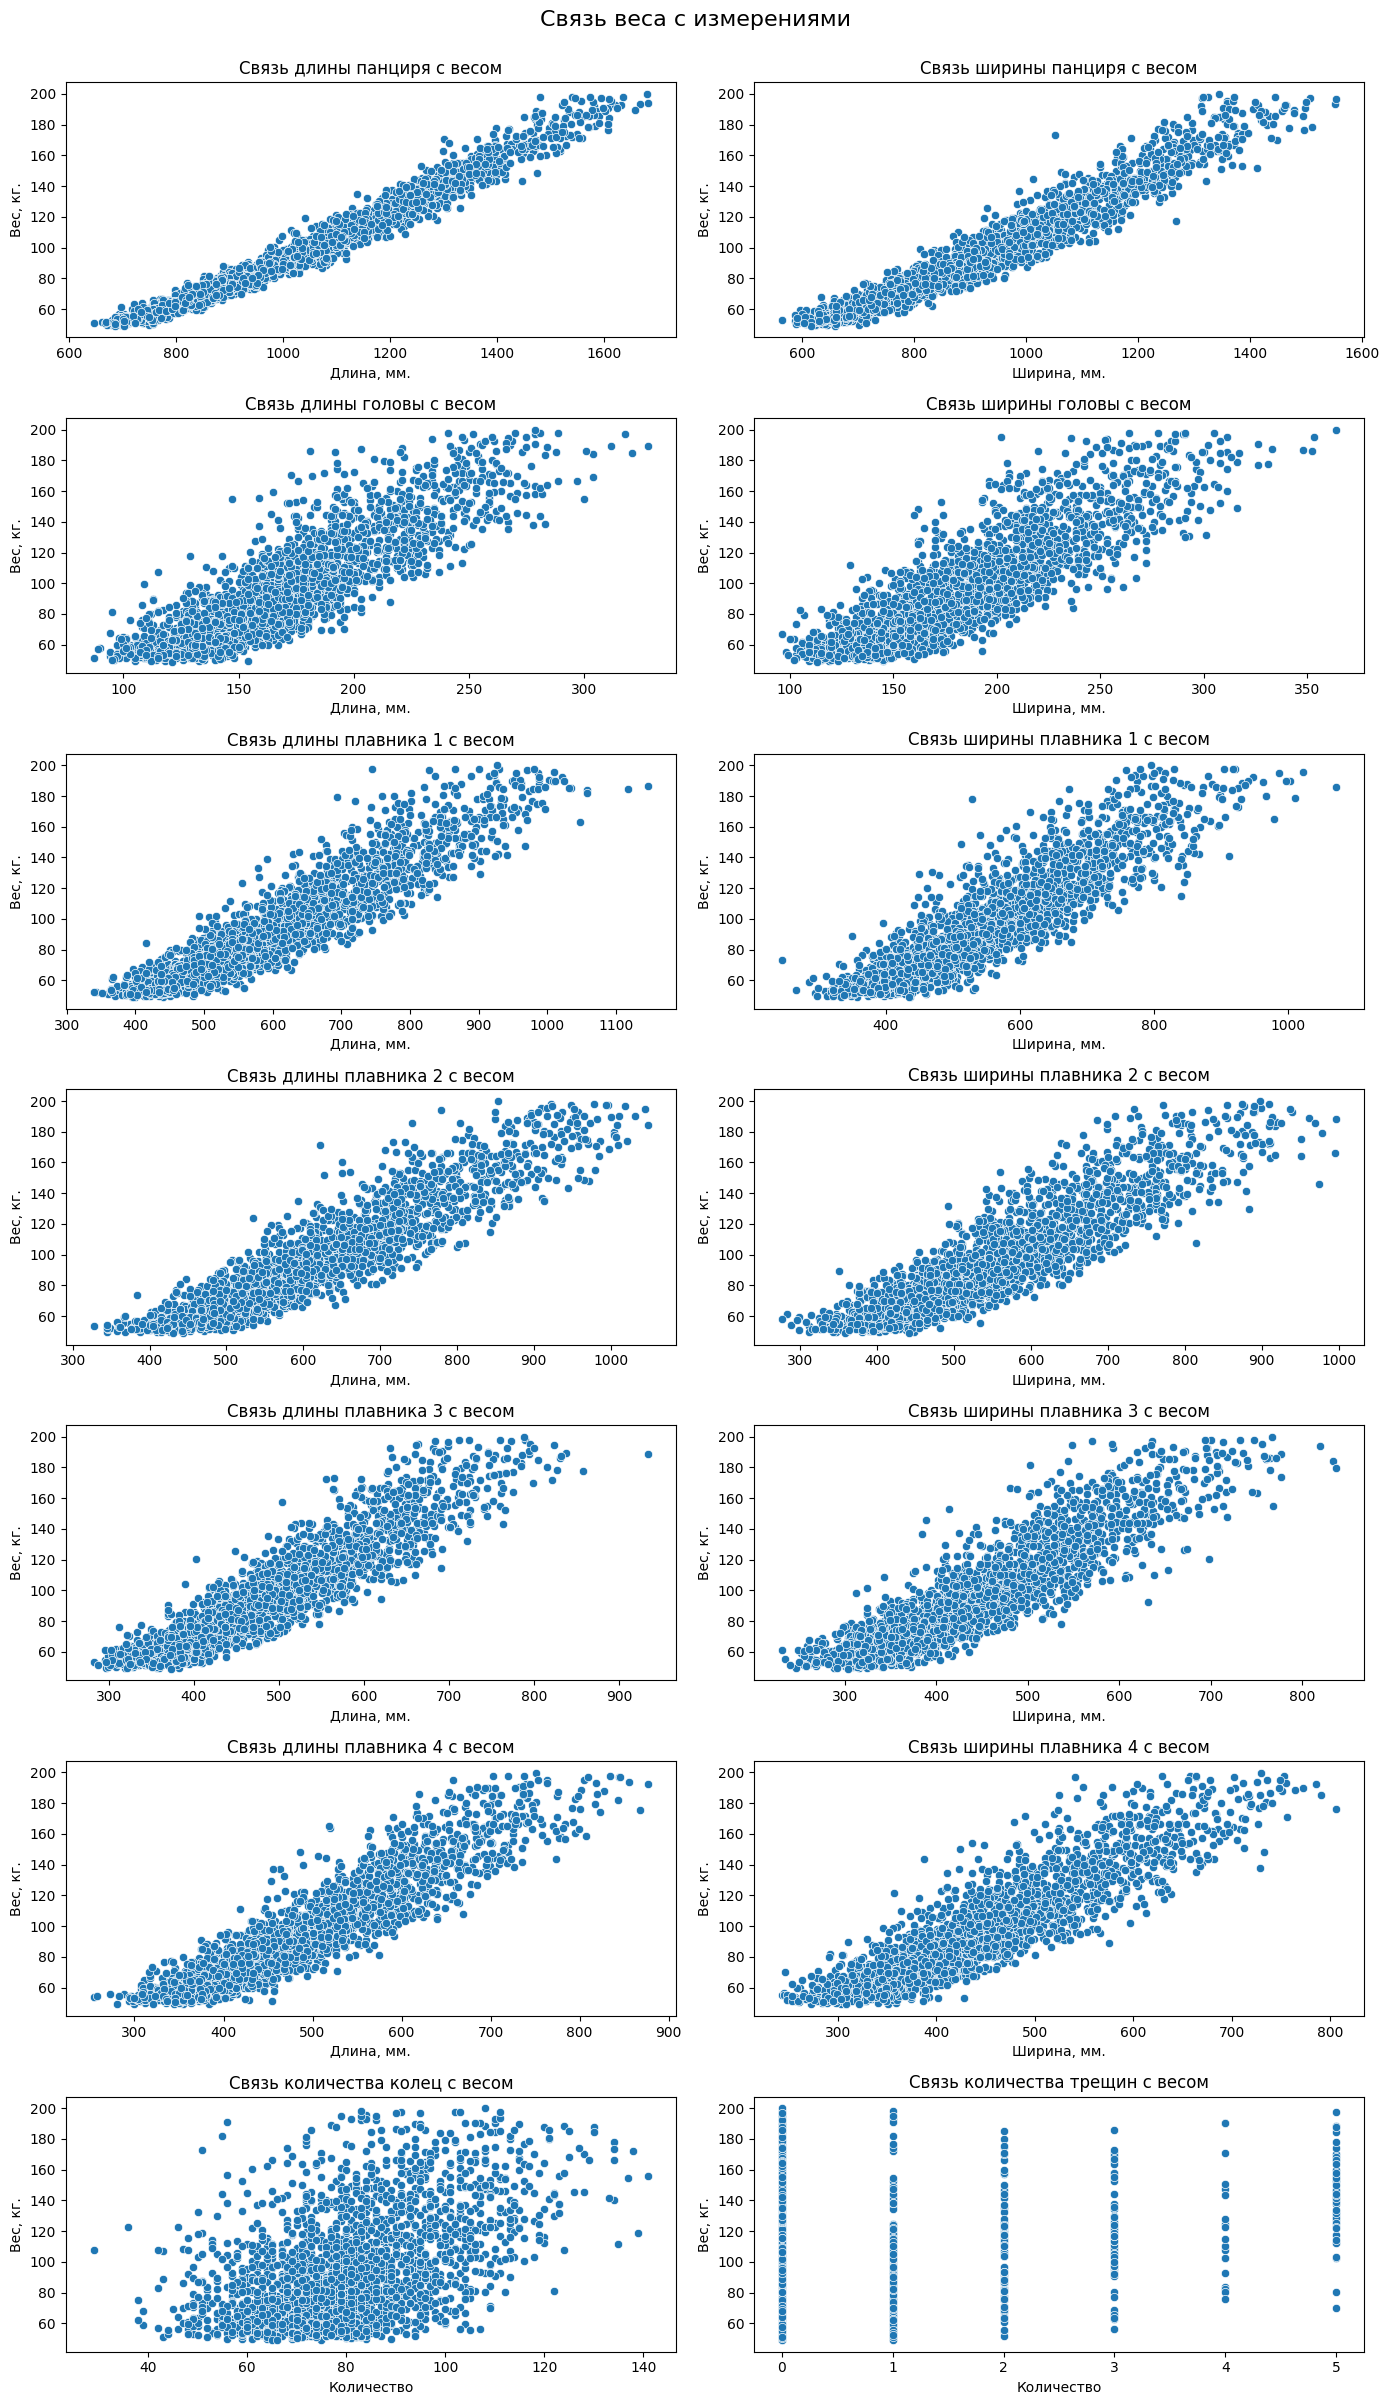

In [18]:
graph_data = [["Связь длины панциря с весом", 'shell_length', 'weight', None, "Длина, мм.", "Вес, кг."],
              ["Связь ширины панциря с весом", 'shell_width', 'weight', None, "Ширина, мм.", "Вес, кг."],
              ["Связь длины головы с весом", 'head_length', 'weight', None, "Длина, мм.", "Вес, кг."],
              ["Связь ширины головы с весом", 'head_width', 'weight', None, "Ширина, мм.", "Вес, кг."],
              ["Связь длины плавника 1 с весом", 'flipper_length_1', 'weight', None, "Длина, мм.", "Вес, кг."],
              ["Связь ширины плавника 1 с весом", 'flipper_width_1', 'weight', None, "Ширина, мм.", "Вес, кг."],
              ["Связь длины плавника 2 с весом", 'flipper_length_2', 'weight', None, "Длина, мм.", "Вес, кг."],
              ["Связь ширины плавника 2 с весом", 'flipper_width_2', 'weight', None, "Ширина, мм.", "Вес, кг."],
              ["Связь длины плавника 3 с весом", 'flipper_length_3', 'weight', None, "Длина, мм.", "Вес, кг."],
              ["Связь ширины плавника 3 с весом", 'flipper_width_3', 'weight', None, "Ширина, мм.", "Вес, кг."],
              ["Связь длины плавника 4 с весом", 'flipper_length_4', 'weight', None, "Длина, мм.", "Вес, кг."],
              ["Связь ширины плавника 4 с весом", 'flipper_width_4', 'weight', None, "Ширина, мм.", "Вес, кг."],
              ["Связь количества колец с весом", 'circle_count', 'weight', None, "Количество", "Вес, кг."],
              ["Связь количества трещин с весом", 'shell_crack', 'weight', None, "Количество", "Вес, кг."]]

fig, axes = plt.subplots(7, 2, figsize=(14, 24))

i = 0
for kwargs in graph_data:
    row = i // 2
    col = i % 2
    i += 1
    kwargs.append(axes[row, col])
    draw_scatterplot_grid(df, *kwargs)

plt.suptitle("Связь веса с измерениями", fontsize=16, y=1)
plt.tight_layout()
plt.show()

**Выводы:**
- В значениях длины и ширины панциря были обнаружен выбросы, связанные с некорректным вводом данных. Они были скорректированы путем деления на 10.
- Параметры измерений после коррекции выглядят правдоподобно: распределения длины и ширины передних и задних ласт практически совпадают попарно; распределения измерений головы и панциря похожи.
- Диаграммы плотности имеют тяжелые правые хвосты, а среднее смещено в большую сторону от медианы. Такие формы графиков распределений отражают особенности роста черепах `Chelonia mydas`.
- На диаграммах видна линейная связь веса с параметрами измерений панциря, плавников и головы. 
- Наименьший разброс значений относительно линейной зависимости с весом - у параметров панциря;
- У параметров ласт и головы диапазон выбросов относительно линейной зависимости с весом примерно одинаковый;
- Самый сильный разброс - у количества колец. Связь этого параметра с весом довольно слабая.
- Связь веса с количеством трещин отсутствует.

### 2.4. Исследование корреляции веса с параметрами измерений.

- Построим тепловую карту корреляции Спирмена для веса и числовых параметров. Корреляция Спирмена используется потому, что есть столбцы с небольшим количеством упорядоченных дискретных числовых значений (`circle_count`, `shell_crack`, `measure_count`):

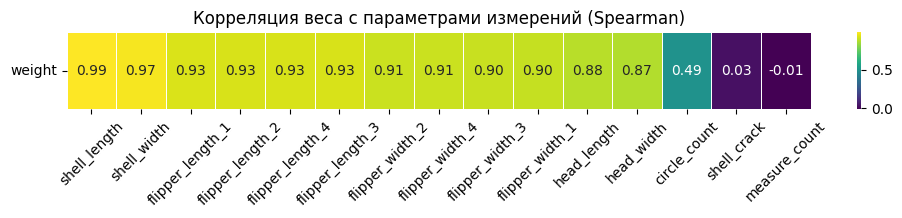

In [19]:
corr_cols = int_cols.copy()
corr_cols.append('weight')
s_corr = pd.DataFrame(df[corr_cols].corr(numeric_only=True, method='spearman')['weight'].drop('weight').sort_values(ascending=False)).T
draw_heatmap(s_corr, 
             "Корреляция веса с параметрами измерений (Spearman)",
             figsize=(12, 1))

Видна сильная линейная корреляция веса с измерениями панциря и длиной ласт. Немного слабее корреляция с шириной ласт и измерениями головы, самая слабая - с количеством колец. Корреляция с количеством трещин и измерений отсутствует.

### 2.5. Проверка на мультиколлинеарность.
Данные представлены наборами парных признаков, которые могут быть близки для каждой особи (например, длина и ширина левых и правых ласт). Их распределение также имеет похожий вид. Из этого можно заключить, что соответствующие столбцы в матрице признаков будут линейно зависимы, а матрица - близка к вырожденной, что окажет влияние на устойчивость решения задачи оптимизации. Проверим попарную линейную зависимость признаков при помощи корреляционной матрицы Пирсона:

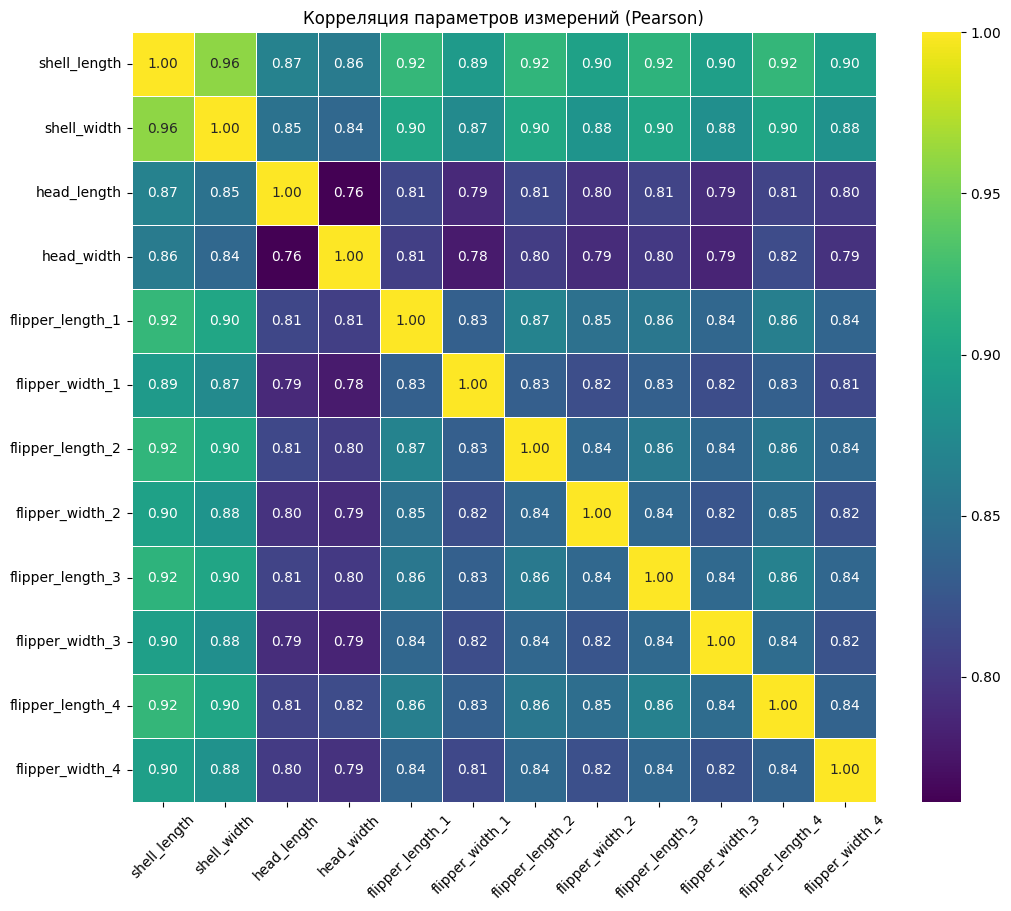

In [20]:
corr_cols = int_cols.copy()
corr_cols.remove('circle_count')
corr_cols.remove('measure_count')
corr_cols.remove('shell_crack')
s_corr = pd.DataFrame(df[corr_cols].corr(numeric_only=True, method='pearson'))
draw_heatmap(s_corr, 
             "Корреляция параметров измерений (Pearson)",
             figsize=(12, 10))

Наибольшую линенйую зависимость друг с другом и с прочими параметрами показывают измерения панциря. Все измерения ласт коррелируют друг с другом примерно одинаково; чуть меньше зависимость с другими признаками - у размеров головы. В целом можно сказать, что в матрице признаков присутствует сильная мультиколлинеарность, которая будет влиять на устойчивость решения. Чтобы ее уменьшить, можно попробовать заменить пары зависимых признаков на их произведение и обучить модель на этих данных.

**Выводы**:
- Были обнаружены и удалены записи с нулевым весом в количестве 3 шт. Новое количество строк в датасете - 2393.
- Распределение и диапазон значений для измеренных параметров соответствуют характерным значениям для `Chelonia mydas`.
- Зависимость веса черепах от измерений близка к линейной с разным количеством отклонений: наименьшее отклонение от линейной зависимости - у параметров панциря, больший разброс значений - у параметров головы и ласт. Наибольший разброс - у количества колец.
- Корреляция Спирмена подтверждает заключения, сделанные на основании графиков: видна сильная линейная зависимость веса от параметров панциря, ласт и головы, самая слабая корреляция - с количеством колец. Корреляция с количеством трещин и измерений отсутствует. Последние два параметра можно исключить из обучения модели.
- В матрице признаков присутствует сильная мультиколлинеарность, столбцы признаков близки к линейно зависимым, а матрица - к вырожденной. Можно попробовать избежать мультиколлинеарности путем комбинации зависимых столбцов в дополнительные признаки и обучить модель на этих новых признаках.

## 3. Подготовка данных для машинного обучения.
Сначала необходимо определить набор признаков, которые будут использоваться при обучении модели. 
- Столбцы `shell_crack` и `measure_count` не влияют на вес, поэтому их можно исключить из обучающего датасета.

In [21]:
# Формируем данные для модели
ml_cols = ['shell_length',
           'shell_width',
           'head_length',
           'head_width',
           'flipper_length_1',
           'flipper_width_1',
           'flipper_length_2',
           'flipper_width_2',
           'flipper_length_3',
           'flipper_width_3',
           'flipper_length_4',
           'flipper_width_4',
           'circle_count',
           'weight']

df_learn = df[ml_cols]
display(df_learn.head(10))

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,weight
8,742,652,118,147,411,386,507,389,414,368,311,325,66,56.352
11,1336,1318,207,248,845,704,661,768,587,686,661,585,111,154.074
16,1010,926,216,156,562,488,529,432,467,434,553,463,76,87.695
21,982,940,187,157,518,557,545,463,497,511,541,479,103,92.707
23,887,813,149,140,578,514,538,472,462,308,408,396,70,75.829
27,754,653,121,175,508,409,437,412,364,321,364,330,75,55.668
29,1203,1048,210,197,701,705,602,629,566,506,479,465,107,120.618
35,843,771,176,170,461,489,518,429,387,393,410,375,77,70.145
36,922,845,152,174,541,504,576,530,483,419,506,373,59,87.982
37,1113,836,129,205,697,655,652,556,549,498,523,417,81,98.670


- Опишем необходимые функции:

In [22]:
# Разделение выборок
def split_data(X, y):
    X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=24, shuffle=True)
    X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=24, shuffle=True)
    print(f"Размеры выборок: \n\tобучающая: {len(X_train)}; \n\tвалидационная: {len(X_val)}; \n\tтестовая: {len(X_test)}.")
    
    return X_train, X_val, X_test, y_train, y_val, y_test

# Масштабирование выборок
def scale_data(X_train, X_val, X_test, method='standard'):
    if method == 'standard':
        mean = X_train.mean()
        std = X_train.std()
        X_train_scaled = (X_train - mean) / std
        X_val_scaled = (X_val - mean) / std
        X_test_scaled = (X_test - mean ) / std
    elif method == 'minmax':
        min_val = X_train.min()
        max_val = X_train.max()
        X_train_scaled = (X_train - min_val) / (max_val - min_val)
        X_val_scaled = (X_val - min_val) / (max_val - min_val)
        X_test_scaled = (X_test - min_val) / (max_val - min_val)
    elif method == 'none':
        X_train_scaled, X_val_scaled, X_test_scaled = X_train, X_val, X_test
    return X_train_scaled, X_val_scaled, X_test_scaled

- Разделим датасет на обучающую, валидационную и тестовую выборки в отношении 60%/20%/20%:

In [23]:
y = df_learn['weight']
X = df_learn.drop('weight', axis=1)

X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)

Размеры выборок: 
	обучающая: 1435; 
	валидационная: 479; 
	тестовая: 479.


- Подготовим наборы данных с разной нормализацией:

In [24]:
scaled_data = {"none": [X_train, X_val, X_test],
               "standard": scale_data(X_train, X_val, X_test, method='standard'),
               "minmax": scale_data(X_train, X_val, X_test, method='minmax')}

X_train_scaled = {name: value[0] for name, value in scaled_data.items()}
X_val_scaled = {name: value[1] for name, value in scaled_data.items()}
X_test_scaled = {name: value[2] for name, value in scaled_data.items()}

## 4. Обучение линейных моделей.

- Опишем необходимые функции:

In [25]:
# Создание моделей
def create_models():
    models = [DummyRegressor(strategy='mean'),
              LinearRegression(),
              SGDRegressor(loss='squared_error', random_state=56),
              SGDRegressor(loss='squared_epsilon_insensitive', epsilon=0, random_state=56)]

    for d in range(-3, 2):
        models.append(Ridge(alpha=10**d, random_state=56))
    for d in range(-3, 2):
        models.append(Lasso(alpha=10**d, random_state=56))

    return models

# Обучение всех моделей
def train_all_models(X_train_scaled, y_train):
    all_models = {}
    for norm_name, value in X_train_scaled.items():
        all_models[norm_name] = []
        for model in create_models():
            model.fit(value, y_train)
            all_models[norm_name].append(model)
    return all_models

# Запуск модели и подсчет метрик
def calc_metrics(model, X, y):
    y_pred = model.predict(X)
    mse = mean_squared_error(y, y_pred)
    rmse = math.sqrt(mean_squared_error(y, y_pred))
    mae = mean_absolute_error(y, y_pred)
    mape = mean_absolute_percentage_error(y, y_pred) * 100.0
    r2 = r2_score(y, y_pred)
    return [mse, rmse, mae, mape, r2]

# Запуск всех моделей и вычислений метрик
def run_models(all_models, scaled_data, y):
    metrics = []
    for norm_name, models in all_models.items():
        metrics += [[model, norm_name] + calc_metrics(model, scaled_data[norm_name], y) for model in models]
    df_scores = pd.DataFrame(metrics, columns=['Model', 'Normalization', 'MSE', 'RMSE', 'MAE', 'MAPE', 'R2'])
    return df_scores

def display_df(df):
    display(df.style.format("{:.8f}", subset=df.select_dtypes(include="number").columns))

- Обучим на тренировочных данных следующие модели:
1. Простейшая модель, предсказывающая среднее. Она будет взята за базовую.
2. Линейная регрессия с MSE.
3. Стохастический градиентный спуск с функцией потерь MSE;
4. Стохастический градиентный спуск с функцией потерь MAE;
5. Линейная регрессия с регуляризацией L2 (Ridge) с параметром `alpha` от $0.001$ до $10$ по логарифмической шкале с основанием $10$;
6. Линейная регрессия с регуляризацией L1 (Lasso) с параметром `alpha` от $0.001$ до $10$ по логарифмической шкале с основанием $10$;

In [26]:
all_models = train_all_models(X_train_scaled, y_train)
df_train_scores = run_models(all_models, X_train_scaled, y_train)
display_df(df_train_scores.sort_values(by="MAE"))

,Model,Normalization,MSE,RMSE,MAE,MAPE,R2
25,"Lasso(alpha=0.1, random_state=56)",standard,19.68773199,4.43708598,3.46610862,3.82966414,0.98383885
38,"Lasso(alpha=0.01, random_state=56)",minmax,19.68171165,4.43640752,3.47022489,3.84258590,0.98384379
24,"Lasso(alpha=0.01, random_state=56)",standard,19.67277580,4.43540030,3.47306359,3.85286902,0.98385113
34,"Ridge(alpha=0.1, random_state=56)",minmax,19.67892320,4.43609324,3.47317697,3.85271245,0.98384608
37,"Lasso(alpha=0.001, random_state=56)",minmax,19.67265951,4.43538719,3.47363992,3.85424372,0.98385122
21,"Ridge(alpha=1, random_state=56)",standard,19.67416190,4.43555655,3.47368692,3.85438856,0.98384999
33,"Ridge(alpha=0.01, random_state=56)",minmax,19.67257871,4.43537808,3.47394934,3.85531214,0.98385129
20,"Ridge(alpha=0.1, random_state=56)",standard,19.67252665,4.43537221,3.47400663,3.85548790,0.98385133
23,"Lasso(alpha=0.001, random_state=56)",standard,19.67251707,4.43537113,3.47403566,3.85548455,0.98385134
32,"Ridge(alpha=0.001, random_state=56)",minmax,19.67251024,4.43537036,3.47403693,3.85558655,0.98385135


- Запустим модели на валидационной выборке и выведем метрики:

In [27]:
df_val_scores = run_models(all_models, X_val_scaled, y_val)
display_df(df_val_scores.sort_values(by="MAE"))

,Model,Normalization,MSE,RMSE,MAE,MAPE,R2
26,"Lasso(alpha=1, random_state=56)",standard,24.44850893,4.94454335,3.68357980,3.92465265,0.97937067
25,"Lasso(alpha=0.1, random_state=56)",standard,23.21223474,4.81790771,3.71704576,4.11897543,0.98041382
39,"Lasso(alpha=0.1, random_state=56)",minmax,23.98817649,4.89777260,3.72044021,4.05118801,0.97975910
38,"Lasso(alpha=0.01, random_state=56)",minmax,23.21153927,4.81783554,3.72172106,4.13359177,0.98041441
37,"Lasso(alpha=0.001, random_state=56)",minmax,23.20423690,4.81707763,3.72695991,4.14775806,0.98042057
24,"Lasso(alpha=0.01, random_state=56)",standard,23.20903704,4.81757585,3.72729342,4.14718257,0.98041652
23,"Lasso(alpha=0.001, random_state=56)",standard,23.20297311,4.81694645,3.72740392,4.14912139,0.98042164
11,"Lasso(alpha=0.1, random_state=56)",none,23.20495502,4.81715217,3.72762796,4.14933824,0.98041997
9,"Lasso(alpha=0.001, random_state=56)",none,23.20500530,4.81715739,3.72773700,4.14961502,0.98041993
1,LinearRegression(),none,23.20502039,4.81715895,3.72773895,4.14961772,0.98041991


- Почти все модели показывают результаты, значительно лучшие, чем базовая модель `DummyRegressor`, возвращающая среднее.
- На валидационной выборке лучший результат по метрике MAE показывает Lasso со стандартизацией и коэффициентом регуляризации 1, однако у этой модели одно из наименьших значение объясняемой вариативности R2 и большое среднеквадратичное отклонение MSE. По последним двум параметрам лучше выглядит модель `Lasso` с коэффициентом 0.1. 
- Модель `Lasso` с коэффициентом 0.1 объясняет 98% вариативности веса и ошибается на валидационной выборке в среднем на 3.72 кг. Эти результаты удовлетворяют постановке задачи, а метрики этой модели в совокупности лучше, чем у остальных, поэтому мы выберем ее для предсказания на тестовой выборке.
- Стохастический градиентный спуск на ненормализованных данных показывает непредсказуемые результаты и не может быть использован.
- Модель `Lasso` с коэффициентом регуляризации 10 с нормализацией `minmax` показывает такой же результат, как `DummyRegressor`, потому что из-за слишком сильной регуляризации все коэффициенты становятся нулевыми.

Запустим выбранную модель на тестовых данных и измерим значение метрик и их изменение относительно тренировочных данных:

In [28]:
# Выбранная модель
best_model_name = 'Lasso(alpha=0.1, random_state=56)'
best_model_norm = 'standard'

def get_best_model(df_scores, model_name, norm_name):
    model_row = df_scores[(df_scores['Model'].apply(str) == model_name) & (df_scores['Normalization'] == norm_name)]
    best_model = model_row.iloc[0, 0]
    train_result = model_row.iloc[0, 2:]
    return best_model, train_result

best_model, train_result = get_best_model(df_train_scores, best_model_name, best_model_norm)

# Метрики модели на тестовой выборке
test_result = pd.Series(calc_metrics(best_model, X_test_scaled[best_model_norm], y_test),
                           index=['MSE', 'RMSE', 'MAE', 'MAPE', 'R2'])

#Разница в %
train_test_diff = (test_result - train_result) / train_result * 100
display(pd.DataFrame({"Тренировочная выборка": train_result,
                      "Тестовая выборка": test_result,
                      "Разница, %": train_test_diff.map('{:.2f}%'.format)}))

,Тренировочная выборка,Тестовая выборка,"Разница, %"
MSE,19.687732,22.821791,15.92%
RMSE,4.437086,4.777216,7.67%
MAE,3.466109,3.636270,4.91%
MAPE,3.829664,3.848788,0.50%
R2,0.983839,0.981314,-0.26%


Метрики на тестовой выборке ожидаемо оказались хуже, чем на тренировочной, однако разница невелика, и модель не демонстрирует переобучения. Полученные параметры соответствуют условиям, сформулированным в постановке задачи. Модель может быть использована в функции предсказания веса.

- Оценим важность признаков по абсолютной величине коэффициентов модели:

In [29]:
coef = pd.DataFrame({"Coef": np.abs(best_model.coef_)}, index=X.columns).sort_values(by='Coef', ascending=False)
display(coef.style.background_gradient(cmap='viridis'))

,Coef
shell_length,13.971252
shell_width,5.713219
flipper_length_1,2.380411
flipper_length_2,1.840261
flipper_length_3,1.812000
flipper_width_4,1.745295
flipper_width_3,1.722743
flipper_length_4,1.604032
flipper_width_1,1.548691
head_width,1.273075


Наиболее важными признаками являются длина и ширина панциря, а также длина ласт. Можно видеть, что признаки упорядочены по коэффициентам модели примерно так же, как по коэффициентам корреляции Спирмена.

**Выводы:**
- На тренировочных выборках с тремя типами нормализации были обучены следующие модели:
    1. Простейшая модель, предсказывающая среднее. Она будет взята за базовую.
    2. Линейная регрессия с MSE.
    3. Стохастический градиентный спуск с функцией потерь MSE;
    4. Стохастический градиентный спуск с функцией потерь MAE;
    5. Линейная регрессия с регуляризацией L2 (Ridge) с параметром `alpha` от $0.001$ до $10$ по логарифмической шкале с основанием $10$;
    6. Линейная регрессия с регуляризацией L1 (Lasso) с параметром `alpha` от $0.001$ до $10$ по логарифмической шкале с основанием $10$;
- Стохастический градиентный спуск на ненормализованных данных показывает непредсказуемые результаты и не может быть использован.
- Модель `Lasso` с коэффициентом регуляризации 10 с нормализацией `minmax` показывает такой же результат, как `DummyRegressor`, потому что из-за слишком сильной регуляризации все коэффициенты становятся нулевыми.
- По результатам запуска моделей на валидационных выборках с тремя типами нормализации была выбрана модель `Lasso` с параметром регуляризации $0.1$ и стандартизацией. Она объясняет 98% вариативности веса и ошибается на валидационной выборке в среднем на 3.72 кг. Эти результаты удовлетворяют постановке задачи, а метрики этой модели в совокупности лучше, чем у остальных.
- Выбранная модель была запущена на тестовой выборке. Метрики полученных результатов ожидаемо оказались хуже, чем на тренировочной выборке, однако разница невелика и не говорит о переобучении модели.
- Признаки упорядочены по важности (величине коэффициентов модели) примерно так же, как на диаграмме корреляции Спирмена. Наиболее важными признаками являются длина и ширина панциря, а также длина ласт.
    

## 5. Уменьшение количества признаков
Как было замечено, столбцы парных признаков близки к линейно зависимым. Попробуем заменить эти пары их произведением и обучим модели на меньшем количестве признаков.

In [30]:
# Преобразование матрицы признаков
def transform_x(X):
    X_new = X.copy()
    X_new['head_sq'] = X['head_length'].astype('int32') * X['head_width']
    X_new['shell_sq'] = X['shell_length'].astype('int32') * X['shell_width']
    X_new['flipper_sq_1'] = X['flipper_length_1'].astype('int32') * X['flipper_width_1']
    X_new['flipper_sq_2'] = X['flipper_length_2'].astype('int32') * X['flipper_width_2']
    X_new['flipper_sq_3'] = X['flipper_length_3'].astype('int32') * X['flipper_width_3']
    X_new['flipper_sq_4'] = X['flipper_length_4'].astype('int32') * X['flipper_width_4']

    X_new.drop(columns=['head_length',
            'head_width',
            'shell_length',
            'shell_width',
            'flipper_length_1',
            'flipper_width_1',
            'flipper_length_2',
            'flipper_width_2',
            'flipper_length_3',
            'flipper_width_3',
            'flipper_length_4',
            'flipper_width_4'],
            inplace=True)
    return X_new

- Преобразуем выборки, сформированные ранее:

In [31]:
X_new = transform_x(X)
X_new_train = transform_x(X_train)
X_new_val = transform_x(X_val)
X_new_test = transform_x(X_test)

scaled_new_data = {"none": [X_new_train, X_new_val, X_new_test],
               "standard": scale_data(X_new_train, X_new_val, X_new_test, method='standard'),
               "minmax": scale_data(X_new_train, X_new_val, X_new_test, method='minmax')}

X_new_train_scaled = {name: value[0] for name, value in scaled_new_data.items()}
X_new_val_scaled = {name: value[1] for name, value in scaled_new_data.items()}
X_new_test_scaled = {name: value[2] for name, value in scaled_new_data.items()}

- Построим тепловую карту корреляции Пирсона для новых признаков:

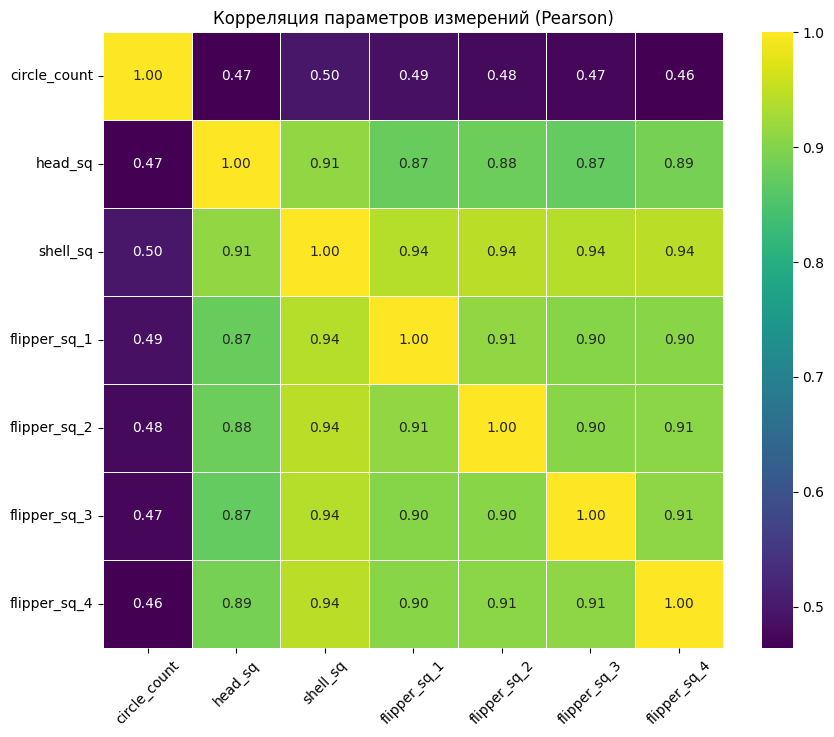

In [32]:
s_corr = pd.DataFrame(X_new.corr(numeric_only=True, method='pearson'))
draw_heatmap(s_corr, 
             "Корреляция параметров измерений (Pearson)",
             figsize=(10, 8))

- Обучим модель на тренировочной выборке:

In [33]:
all_new_models = train_all_models(X_new_train_scaled, y_train)
df_new_train_scores = run_models(all_new_models, X_new_train_scaled, y_train)
display_df(df_new_train_scores.sort_values(by="MAE"))

,Model,Normalization,MSE,RMSE,MAE,MAPE,R2
1,LinearRegression(),none,17.57304243,4.19202128,3.20081354,3.34446233,0.98557474
29,LinearRegression(),minmax,17.57304243,4.19202128,3.20081354,3.34446233,0.98557474
15,LinearRegression(),standard,17.57304243,4.19202128,3.20081354,3.34446233,0.98557474
4,"Ridge(alpha=0.001, random_state=56)",none,17.57304243,4.19202128,3.20081354,3.34446233,0.98557474
5,"Ridge(alpha=0.01, random_state=56)",none,17.57304243,4.19202128,3.20081354,3.34446233,0.98557474
6,"Ridge(alpha=0.1, random_state=56)",none,17.57304243,4.19202128,3.20081354,3.34446233,0.98557474
7,"Ridge(alpha=1, random_state=56)",none,17.57304243,4.19202128,3.20081355,3.34446233,0.98557474
8,"Ridge(alpha=10, random_state=56)",none,17.57304243,4.19202128,3.20081364,3.34446229,0.98557474
9,"Lasso(alpha=0.001, random_state=56)",none,17.57304244,4.19202128,3.20081400,3.34446216,0.98557474
18,"Ridge(alpha=0.001, random_state=56)",standard,17.57304244,4.19202128,3.20081427,3.34446404,0.98557474


- Оценим модели на валидационной выборке:

In [34]:
df_new_val_scores = run_models(all_new_models, X_new_val_scaled, y_val)
display_df(df_new_val_scores.sort_values(by="MAE"))

,Model,Normalization,MSE,RMSE,MAE,MAPE,R2
17,"SGDRegressor(epsilon=0, loss='squared_epsilon_insensitive', random_state=56)",standard,17.43877189,4.17597556,3.12536271,3.29447253,0.98528540
21,"Ridge(alpha=1, random_state=56)",standard,17.43111988,4.17505927,3.12695047,3.29774455,0.98529185
34,"Ridge(alpha=0.1, random_state=56)",minmax,17.44115662,4.17626108,3.12726281,3.29942732,0.98528338
33,"Ridge(alpha=0.01, random_state=56)",minmax,17.42947160,4.17486187,3.12739499,3.29755771,0.98529324
20,"Ridge(alpha=0.1, random_state=56)",standard,17.42937083,4.17484980,3.12753012,3.29755620,0.98529333
23,"Lasso(alpha=0.001, random_state=56)",standard,17.42771406,4.17465137,3.12757512,3.29757158,0.98529473
32,"Ridge(alpha=0.001, random_state=56)",minmax,17.42939802,4.17485305,3.12761314,3.29757373,0.98529331
19,"Ridge(alpha=0.01, random_state=56)",standard,17.42939805,4.17485306,3.12762680,3.29757370,0.98529331
18,"Ridge(alpha=0.001, random_state=56)",standard,17.42940287,4.17485363,3.12763649,3.29757547,0.98529330
1,LinearRegression(),none,17.42940343,4.17485370,3.12763757,3.29757567,0.98529330


- Лучшие результаты показывает модель стохастического градиентного спуска с лоссом MAE и стандартизацией. Запустим ее на тестовой выборке:

In [35]:
# Выбранная модель
best_new_model_name = "SGDRegressor(epsilon=0, loss='squared_epsilon_insensitive', random_state=56)"
best_new_model_norm = 'standard'

best_new_model, train_new_result = get_best_model(df_new_train_scores, best_new_model_name, best_new_model_norm)

# Метрики модели на тестовой выборке
test_new_result = pd.Series(calc_metrics(best_new_model, X_new_test_scaled[best_new_model_norm], y_test),
                           index=['MSE', 'RMSE', 'MAE', 'MAPE', 'R2'])

#Разница в %
train_new_test_diff = (test_new_result - train_new_result) / train_new_result * 100
display(pd.DataFrame({"Тренировочная выборка": train_new_result,
                      "Тестовая выборка": test_new_result,
                      "Разница, %": train_new_test_diff.map('{:.2f}%'.format)}))

,Тренировочная выборка,Тестовая выборка,"Разница, %"
MSE,17.605679,18.521268,5.20%
RMSE,4.195912,4.303634,2.57%
MAE,3.201168,3.304549,3.23%
MAPE,3.343751,3.347062,0.10%
R2,0.985548,0.984836,-0.07%


- Оценим значимость признаков по величине коэффициентов:

In [36]:

coef = pd.DataFrame({"Coef": np.abs(best_new_model.coef_)}, index=X_new.columns).sort_values(by='Coef', ascending=False)
display(coef.style.background_gradient(cmap='viridis'))

,Coef
shell_sq,17.955342
flipper_sq_3,3.725105
flipper_sq_1,3.694482
flipper_sq_2,3.582782
flipper_sq_4,3.480375
head_sq,2.957138
circle_count,0.535337


**Выводы:**
- После замены признаков на новые линейная зависимость осталась высокой, однако модели, обученные на новых признаках показывают лучший результат: на одинаковой тестовой выборке лучшая модель на новых признаках имеет MAE 3.30 кг. против 3.64 у лучшей модели на старых признаках. Метрика R2 - 0.984 против 0.981. 
- Из новых признаков наиболее важным оказывается размер панциря (произведение длины на ширину). Размеры ласт имеют примерно одинаковые коэффициенты; менее важен размер головы; количество колец - на последнем месте.
- Ухудшение метрик на тестовой выборке по отношению к тренировочной оказалось меньше на новых признаках. Это говорит о лучшем качестве обучения и устойчивости. Для функции прогнозирования предлагается взять модель, обученную на новых признаках.

## 6. Разработка функции предсказания веса по результатам измерений.
- Напишем функцию Python для предсказания веса по результатам измерений. Она не будет требовать для использования никаких дополнительных пакетов, все вычисления будут производиться стандартными средствами Python. Параметрами функции будут результаты измерений из исходного датасета, а целевое значение будет вычисляться при помощи коэффициентов модели, обученной на новых признаках.
- Выведем коэффициенты и смещение лучшей модели, а также параметры нормализации по тренировочной выборке:

In [37]:
# Порядок следования признаков
print("Порядок следования признаков: ", X_new_train.columns.to_list())
# Среднее для нормализации
print("Среднее по тренировочной выборке: ", X_new_train.mean().to_list())
# Стандартное отклонение для нормализации
print("Стандартное отклонение по тренировочной выборке: ", X_new_train.std().to_list())
# Коэффициенты линейной модели
print("Коэффициенты линейной модели: ", best_new_model.coef_)
# Смещение линейной модели
print("Смещение линейной модели: ", best_new_model.intercept_)

Порядок следования признаков:  ['circle_count', 'head_sq', 'shell_sq', 'flipper_sq_1', 'flipper_sq_2', 'flipper_sq_3', 'flipper_sq_4']
Среднее по тренировочной выборке:  [80.53658536585365, 32328.848780487806, 980424.3226480837, 352874.4857142857, 352177.21602787456, 224229.39860627177, 225840.6292682927]
Стандартное отклонение по тренировочной выборке:  [15.726897542865043, 15205.617423559277, 434382.56408829166, 165548.99765553, 160693.45444592639, 103210.59724627629, 102910.51770079405]
Коэффициенты линейной модели:  [ 0.5353372   2.95713797 17.95534207  3.69448214  3.58278162  3.72510545
  3.48037476]
Смещение линейной модели:  [96.30632429]


- Опишем функцию:

In [38]:
def predict_turtle_weight(shell_length,
                          shell_width,
                          head_length,
                          head_width,
                          flipper_length_1,
                          flipper_width_1,
                          flipper_length_2,
                          flipper_width_2,
                          flipper_length_3,
                          flipper_width_3,
                          flipper_length_4,
                          flipper_width_4,
                          circle_count):
    # Коэффициенты линейной модели
    coef = [ 0.5353372 ,  2.95713797, 17.95534207,  3.69448214,  3.58278162,
        3.72510545,  3.48037476]
    # Смещение линейной модели
    intercept = 96.30632429
    # Среднее
    mean = [80.53658536585365,
            32328.848780487806,
            980424.3226480837,
            352874.4857142857,
            352177.21602787456,
            224229.39860627177,
            225840.6292682927]
    # Стандартное отклонение
    std = [15.726897542865043,
            15205.617423559277,
            434382.56408829166,
            165548.99765553,
            160693.45444592639,
            103210.59724627629,
            102910.51770079405]

    # Новые признаки
    new_features = [circle_count,
                    head_length * head_width,
                    shell_length * shell_width,                 
                    flipper_length_1 * flipper_width_1,
                    flipper_length_2 * flipper_width_2,
                    flipper_length_3 * flipper_width_3,
                    flipper_length_4 * flipper_width_4]     
    
    wgt = 0.0
    # Нормализация и вычисление скалярного произведения
    for i in range(len(new_features)):
        wgt += (new_features[i] - mean[i]) / std[i] * coef[i]

    # Добавляем смещение
    return wgt + intercept

- Запустим функцию на тестовой выборке для проверки и посчитаем метрики:

In [39]:
y_new_test_pred = X_test.apply(lambda s: predict_turtle_weight(s['shell_length'].astype('int32'),
                                                                   s['shell_width'].astype('int32'),
                                                                   s['head_length'].astype('int32'),
                                                                   s['head_width'].astype('int32'),
                                                                   s['flipper_length_1'].astype('int32'),
                                                                   s['flipper_width_1'].astype('int32'),
                                                                   s['flipper_length_2'].astype('int32'),
                                                                   s['flipper_width_2'].astype('int32'),
                                                                   s['flipper_length_3'].astype('int32'),
                                                                   s['flipper_width_3'].astype('int32'),
                                                                   s['flipper_length_4'].astype('int32'),
                                                                   s['flipper_width_4'].astype('int32'),
                                                                   s['circle_count'].astype('int32')),
                                                                   axis=1)


print(f"MAE для функции: {mean_absolute_error(y_test, y_new_test_pred):.8f}")
print(f"MSE для функции: {mean_squared_error(y_test, y_new_test_pred):.8f}")
print(f"RMSE для функции: {math.sqrt(mean_squared_error(y_test, y_new_test_pred)):.8f}")
print(f"MAPE для функции: {mean_absolute_percentage_error(y_test, y_new_test_pred) * 100:.8f}")
print(f"R2 для функции: {r2_score(y_test, y_new_test_pred):.8f}")

MAE для функции: 3.30454940
MSE для функции: 18.52126771
RMSE для функции: 4.30363424
MAPE для функции: 3.34706244
R2 для функции: 0.98483552


Метрики совпадают с полученными при запуске модели.

## 7. Выводы


- Для обучения модели был представлен датасет в формате CSV-файла, содержащий сведения об измерениях размеров и веса черепах разных видов. На этапе предобработки данных были в 105 строках (3.71%) были обнаружены пропуски в такие важных для обучения модели признаках, как вес, длина панциря, длина и ширина головы, задних плавников. Пропуски были удалены. Пропуски в строковых столбцах были заполнены значением `undefined`.
- Для дальнейшей работы из датасета были выбраны только строки, относящиеся к виду `Chelonia mydas`. В получившемся датасете были найдены 328 дубликатов, которые были удалены.
- На этапе исследовательского анализа данных были исследованы категориальные, временные и числовые признаки. Единственный категориальный признак `binomial_name` содержит название одного вида черепах (`Chelonia mydas`). Даты измерений содержат корректные данные с 2023 по 2025 год. В числовых признаках обнаружены нулевые значения веса и выбросы в измерениях, связанные с неправильным вводом данных. Данные с нулевым весом были удалены, неверно введенные данные - скорректированы. Подготовленный к обучению модели датасет содержит 2393 строки.
- Исследование корреляции веса с измерениями показало, что наиболее сильно вес коррелирует с измерениями панциря и длиной ласт, немного слабее - с шириной ласт и измерениями головы, менее всего - с количеством колец. Корреляция с количеством трещин и измерений отсутствует.
- В матрице признаков из-за наличия парных признаков присутствует сильная мультиколлинеарность, столбцы признаков близки к линейно зависимым, а матрица - к вырожденной.
- На этапе подготовки данных к машинному обучению данные были разделены на тренировочную, валидационную и тестовую выборки в отношении 60/20/20%. Была проведена нормализация по тренировочной выборке посредством стандартизации и по методу `minmax`.
- На тренировочных выборках с тремя типами нормализации (стандартизация, `minmax`, без нормализации) были обучены следующие модели:
    1. Простейшая модель, предсказывающая среднее. Она взята за базовую.
    2. Линейная регрессия с MSE.
    3. Стохастический градиентный спуск с функцией потерь MSE;
    4. Стохастический градиентный спуск с функцией потерь MAE;
    5. Линейная регрессия с регуляризацией L2 (Ridge) с параметром `alpha` от $0.001$ до $10$ по логарифмической шкале с основанием $10$;
    6. Линейная регрессия с регуляризацией L1 (Lasso) с параметром `alpha` от $0.001$ до $10$ по логарифмической шкале с основанием $10$;
- Была проведена проверка моделей на валидационной выборке, в результате для тестирования была выбрана модель `Lasso` с параметром регуляризации 0.1 и стандартизацией.
- На тестовой выборке основная метрика MAE увеличилась на 4.91%, MAPE - на 0.5%. Метрика R2 уменьшилась на 0.26%. Значение метрики MAE на тестовой выборке - 3.64, т.е. модель ошибается в среднем на 3.64 кг. Модель удовлетворяет поставленным условиям.
- Далее была предпринята попытка уменьшить мультиколлинеарность за счет сокращения парных признаков. Для всех измерений, где присутствуют длина и ширина был введен новый признак - их произведение, а старые признаки удалены. Таким образом были сформированы новые датасеты на основе уже существующих тренировочной, валидационной и тестовой выборок.
- На новых выборках аналогичным образом были обучены такие же модели, проведена проверка на валидационной выборке.
- Лучшие результаты на новых признаках показала модель стохастического градиентного спуска с лоссом MAE и стандартизацией. Она была протестирована на тестовой выборке.
- Результаты, полученные на новых признаках, оказались лучше результатов на полном наборе: На одинаковой тестовой выборке лучшая модель на новых признаках имеет MAE 3.30 кг. против 3.64 у лучшей модели на старых признаках. Метрика R2 - 0.984 против 0.981, MAPE - 3.35 против 3.85. Также на новых признаках меньшей оказалась разница между метриками на тестовой и тренировочной выборках, что говорит о лучшем качестве обучения и устойчивости.
- На основе модели стохастического градиентного спуска с метрикой MAE и стандартизацией была разработана функция Python для оценки веса черепах `Chelonia mydas` на основе измерений. Функция не имеет внешних зависимостей и принимает в качесте параметров результаты измерений из исходного датасета.
- Для предсказания веса других видов черепах также могут быть обучены модели линейной регрессии. Модели можно обучить отдельно для каждого вида (при наличии достаточного количества данных), однако более универсальный подход состоит в кодировании категориального признака (вида черепах) при помощи one-hot encoding. Небольшое количество категорий в датасете позволяет это сделать.
- Можно попробовать реализовать предсказание веса с использованием полиномиальной регрессии степени 2. По скаттерплотам зависимости веса от отдельных измерений можно предположить, что парабола лучше будет приближать их.